In [ ]:
import json
import os
from collections import defaultdict

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from nnsight import LanguageModel
from torch.utils.data import DataLoader
from tqdm import tqdm
from utils import get_memorization_exps

with open("../../env.yml", "r") as f:
    for line in f:
        if "HF_TOKEN" in line or "NDIF_API_KEY" in line:
            os.environ[line.split(":")[0].strip()] = line.split(":")[1].strip()

%load_ext autoreload
%autoreload 2

/disk/u/nikhil/mind/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# model = LanguageModel(
#             "meta-llama/Meta-Llama-3-70B-Instruct",
#             device_map="auto",
#             torch_dtype=torch.float16,
#             dispatch=True,
#         )
model = LanguageModel(
    "meta-llama/Meta-Llama-3-70B-Instruct",
    device_map="auto",
    load_in_4bit=True,
    dtype=torch.float16,
    dispatch=True,
)
# model = LanguageModel("meta-llama/Llama-3.3-70B-Instruct", device_map="auto")

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
Loading checkpoint shards: 100%|██████████| 30/30 [00:35<00:00,  1.18s/it]


In [6]:
all_characters = json.load(
    open("/disk/u/nikhil/mind/data/synthetic_entities/characters.json", "r")
)
all_containers = json.load(
    open("/disk/u/nikhil/mind/data/synthetic_entities/bottles.json", "r")
)
all_states = json.load(
    open("/disk/u/nikhil/mind/data/synthetic_entities/drinks.json", "r")
)

story_templates = json.load(open("/disk/u/nikhil/mind/data/story_templates.json", "r"))

num_samples = 1


In [7]:
dataset = get_memorization_exps(
    model, story_templates, all_characters, all_containers, all_states, num_samples
)
batch_size = 1
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
prompt_len = len(model.tokenizer.encode(dataset[0]["clean_prompt"]))

In [55]:
iia = defaultdict(dict)
with torch.no_grad():
    for token_idx in range(prompt_len - 1, 129, -1):
        for layer_idx in tqdm(
            range(model.config.num_hidden_layers - 1, 0, -5),
            desc="Layers for token: {}".format(token_idx),
        ):
            correct, total = 0, 0
            for bi, batch in enumerate(dataloader):
                corrupt_prompt = batch["corrupt_prompt"]
                clean_prompt = batch["clean_prompt"]
                clean_ans = batch["clean_ans"]
                batch_size = len(clean_ans)

                with model.trace(corrupt_prompt):
                    corrupt_layer_out = (
                        model.model.layers[layer_idx]
                        .output[:, token_idx]
                        .clone()
                        .save()
                    )

                with model.trace(clean_prompt) as tracer:
                    model.model.layers[layer_idx].output[:, token_idx] = (
                        corrupt_layer_out
                    )
                    pred = model.lm_head.output[:, -1].argmax(dim=-1).save()

                for i in range(batch_size):
                    pred_token = model.tokenizer.decode([pred[i]]).lower().strip()
                    clean_answer_token = clean_ans[i].lower().strip()
                    # print(f"Pred: {pred_token} | Target: {clean_answer_token}")

                    if pred_token != clean_answer_token:
                        correct += 1
                    total += 1

                del pred
                torch.cuda.empty_cache()

            iia[token_idx][layer_idx] = correct / total

            # Save iia to a json file
            with open("iia.json", "w") as f:
                json.dump(iia, f)

            # acc = round(correct / total, 2)
            # print(f"Token: {t} | Layer: {layer_idx} | Accuracy: {acc}")

Layers for token: 165:   0%|          | 0/16 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [44]:
# Load iia.json from the disk
with open("../../iia.json", "r") as f:
    iia = json.load(f)


In [45]:
iia = dict(sorted(iia.items(), key=lambda x: x[0]))
iia = {k: dict(sorted(v.items(), key=lambda x: int(x[0]))) for k, v in iia.items()}

In [ ]:
story_tokens = [
    model.tokenizer.decode([t])
    for t in model.tokenizer.encode(dataset[0]["clean_prompt"])[129:]
]

In [56]:
for i, t in enumerate(story_tokens):
    if t == " Max":
        story_tokens[i] = " Character_1"
    elif t == " Karen":
        story_tokens[i] = " Character_2"
    elif t == " tun":
        story_tokens[i] = " Container_1"
    elif t == " dispenser":
        story_tokens[i] = " Container_2"
    elif t == " port":
        story_tokens[i] = " State_1"
    elif t == " juice":
        story_tokens[i] = " State_2"

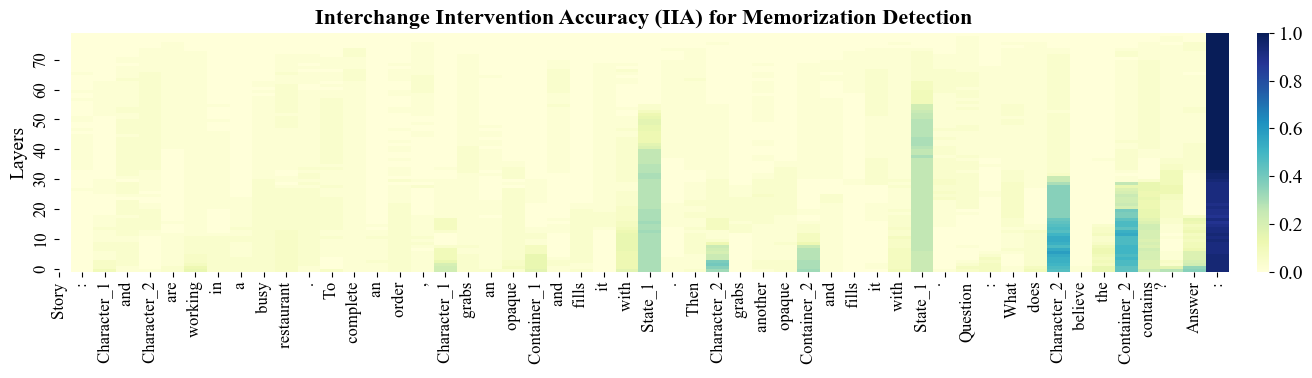

<Figure size 640x480 with 0 Axes>

In [108]:
# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14  # Base font size

# Convert to DataFrame
iia_df = pd.DataFrame(iia)

# Reverse the order of the columns for better visualization
iia_df = iia_df.iloc[::-1]

# Create heatmap
plt.figure(figsize=(15, 4))
sns.heatmap(iia_df, cmap="YlGnBu", cbar_kws={"shrink": 1, "pad": 0.02})
plt.title("Interchange Intervention Accuracy (IIA) for Memorization Detection", fontsize=16, fontweight='bold')
# plt.xlabel("Tokens")
plt.ylabel("Layers", fontsize=14)

plt.gca().set_xticks([i - 0.5 for i in range(len(story_tokens))])

# Create labels with bold formatting using matplotlib's weight parameter
bold_tokens = ['Character_1', 'Character_2', 'Container_1', 'Container_2', 'State_1', 'State_2']

# Set labels first
plt.gca().set_xticklabels(story_tokens, fontsize=12, rotation=90)

y_tick_labels = list(range(0, 80, 10))
num_layers = len(iia_df)
y_tick_positions = [num_layers - 1 - label for label in y_tick_labels if label < num_layers]
y_tick_labels = [label for label in y_tick_labels if label < num_layers]

plt.gca().set_yticks(y_tick_positions)
plt.gca().set_yticklabels(y_tick_labels, fontsize=12)

plt.tight_layout()
plt.show()

# Save the plot
plt.savefig("iia_heatmap.png", dpi=300, bbox_inches="tight")

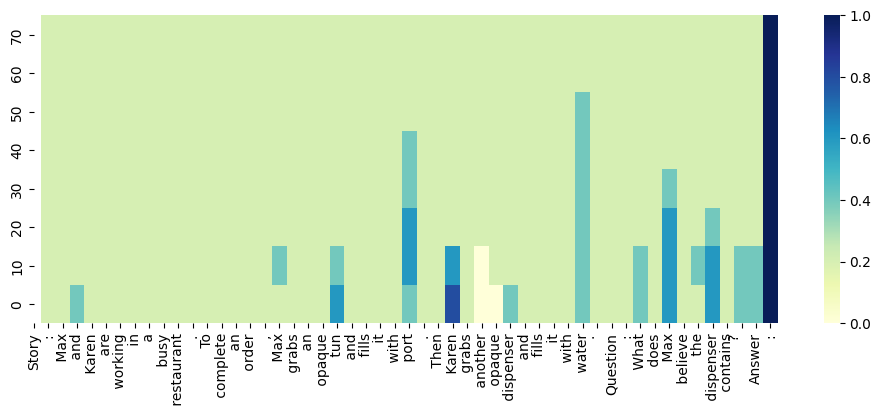

In [32]:
iia_df = pd.DataFrame(iia)

# Reverse the order of the columns
iia_df = iia_df.iloc[::-1]

# Set figure size
plt.figure(figsize=(12, 4))

# Create a heatmap of the DataFrame
sns.heatmap(iia_df, cmap="YlGnBu")

# Replace x-axis labels with the story tokens, centered on bars
plt.xticks(range(len(story_tokens)), story_tokens)
plt.gca().set_xticks([i - 0.5 for i in range(len(story_tokens))])
plt.gca().set_xticklabels(story_tokens)

plt.show()